In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html

In [3]:
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

2024-12-01 20:07:45.706417: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


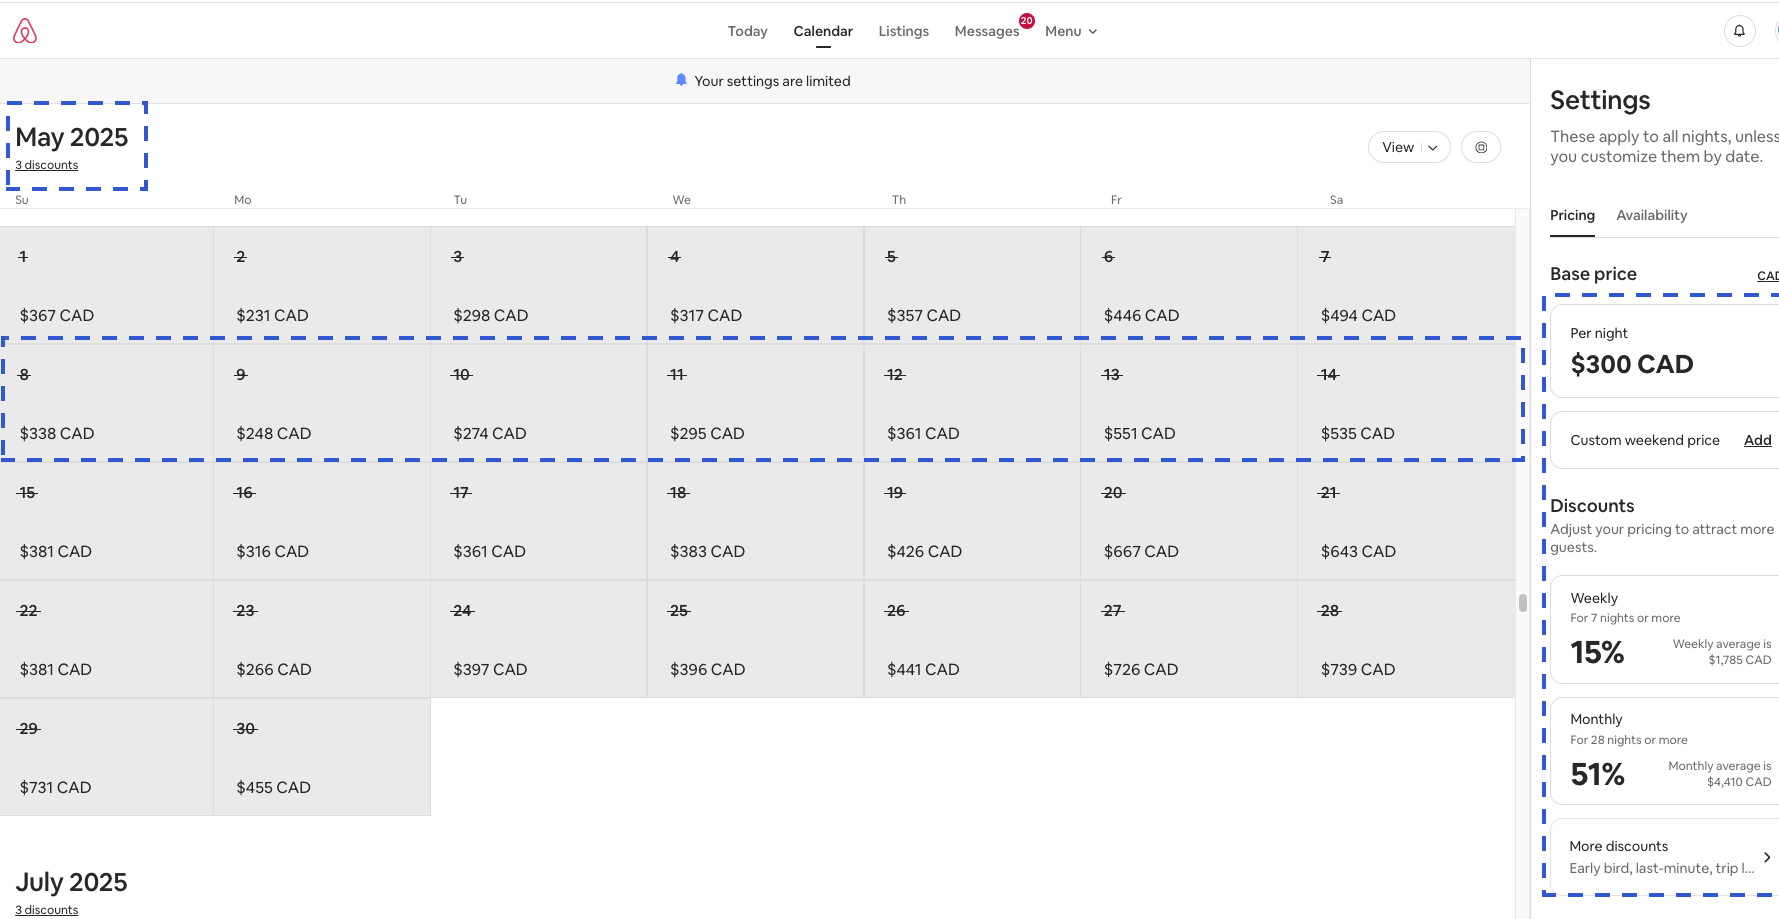

In [4]:
# States = inventory , your price level , demand , competetior price
#Action - Suggested price
# rewards and penality

In [5]:
import gym
import numpy as np
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt

# Custom Airbnb Environment
class AirbnbEnv(gym.Env):
    def __init__(self):
        super(AirbnbEnv, self).__init__()
        self.price_range = (120, 350)  # Price range in dollars
        # Define action and observation spaces
        self.action_space = gym.spaces.Discrete(150)  # 100 discrete price levels
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(4,), dtype=np.float32)  
        # [inventory, price_level, demand, competitor_price]
        self.reset()

    def reset(self):
        # Reset environment state to random initial values
        self.state = np.array([
            np.random.uniform(0.5, 1.0),  # Inventory
            0.5,  # Price level (normalized)
            np.random.uniform(0.5, 1.0),  # Demand
            np.random.uniform(150, 300) / 300  # Competitor price (normalized to [0, 1])
        ])
        return self.state

    def step(self, action):
        # Convert action to actual price that has some locig applied to current inventory and action
        price = self.price_range[0] + action * (self.price_range[1] - self.price_range[0]) / (self.action_space.n - 1)
        inventory, price_level, demand, competitor_price = self.state

        # Calculate reward: Demand and closeness to competitor's price
        if demand < 0.3 and price > competitor_price * 300:
            penalty = -50  # Penalty for overpricing in low demand
        else:
            penalty = 0

        competitor_match_reward = 0.3 * (1 - abs(price - competitor_price * 300) / 300)  # Scaled match reward
        #eg-  0.3 * (1 - (150-200*300/300))
        reward = 0.7 * demand * price + competitor_match_reward + penalty
        # accumulative reward =  0.7 *0.1 * 150 + 15.299999999999999 + 0.2

        # Ensure reward is bounded
        reward = max(-100, min(reward, 100))
        #eg- max(-100, min(25, 100))

        # Update state
        self.state = [
            max(0, inventory - np.random.uniform(0.1, 0.2)),  # Decrease inventory
            action / (self.action_space.n - 1),  # New price level
            np.random.uniform(0, 1),  # New random demand
            np.random.uniform(150, 300) / 300  # New competitor price (normalized)
        ]

        # Check if episode is done (inventory exhausted)
        done = self.state[0] < 0.1
        
        #all DQN env need 4 things returned , states , reward, done , and anything else that we want to pass
        return np.array(self.state), reward, done, {}

# Initialize the environment
env = DummyVecEnv([lambda: AirbnbEnv()])  # Wrap environment for compatibility with SB3

# Initialize DQN model
#PARAMETERS EXPLANATION and Notes 
#learn rate can be 0.01 to 0.0001 , gamma can be 0-1 mostly 0.9 
#exploration_fraction is how much % time model can exploit a random space for new oppertunities eg 10% ,20% randome
#exploration_final_eps is in end of training can model still exploit random spaces typically low at end 
#if you are getting random values use small exploration_final_eps 

model = DQN('MlpPolicy', env, verbose=1, learning_rate=0.01, gamma=0.50, exploration_fraction=0.05, exploration_final_eps=0.01)

# Train the model and collect rewards
reward_list = []  # To store rewards for each step to chack at end 

#custom call back will collect rewards
def custom_train_callback(locals_, globals_):
    # Access environment and rewards during training
    reward_list.append(locals_['rewards'][0])
    return True

# Train the model
model.learn(total_timesteps=90000, callback=custom_train_callback)

/Users/user/opt/miniconda3/envs/langchain2024/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.995    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2504     |
|    time_elapsed     | 0        |
|    total_timesteps  | 21       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.991    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1543     |
|    time_elapsed     | 0        |
|    total_timesteps  | 43       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.986    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 967      |
|    time_elapsed     | 0        |
|    total_timesteps  | 63       |
----------------------------------
----------------------------------
| r

----------------------------------
| rollout/            |          |
|    exploration_rate | 0.914    |
| time/               |          |
|    episodes         | 84       |
|    fps              | 235      |
|    time_elapsed     | 1        |
|    total_timesteps  | 393      |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 26.4     |
|    n_updates        | 73       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.909    |
| time/               |          |
|    episodes         | 88       |
|    fps              | 241      |
|    time_elapsed     | 1        |
|    total_timesteps  | 413      |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 24       |
|    n_updates        | 78       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

----------------------------------
| rollout/            |          |
|    exploration_rate | 0.837    |
| time/               |          |
|    episodes         | 160      |
|    fps              | 273      |
|    time_elapsed     | 2        |
|    total_timesteps  | 742      |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 19.4     |
|    n_updates        | 160      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.833    |
| time/               |          |
|    episodes         | 164      |
|    fps              | 276      |
|    time_elapsed     | 2        |
|    total_timesteps  | 760      |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 20.8     |
|    n_updates        | 164      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

----------------------------------
| rollout/            |          |
|    exploration_rate | 0.757    |
| time/               |          |
|    episodes         | 236      |
|    fps              | 302      |
|    time_elapsed     | 3        |
|    total_timesteps  | 1104     |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 18.9     |
|    n_updates        | 250      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.753    |
| time/               |          |
|    episodes         | 240      |
|    fps              | 304      |
|    time_elapsed     | 3        |
|    total_timesteps  | 1122     |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 8.59     |
|    n_updates        | 255      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

...

----------------------------------
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18248    |
|    fps              | 285      |
|    time_elapsed     | 309      |
|    total_timesteps  | 88534    |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 21.2     |
|    n_updates        | 22108    |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18252    |
|    fps              | 285      |
|    time_elapsed     | 309      |
|    total_timesteps  | 88553    |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 12.5     |
|    n_updates        | 22113    |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

----------------------------------
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18324    |
|    fps              | 285      |
|    time_elapsed     | 311      |
|    total_timesteps  | 88910    |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 10.4     |
|    n_updates        | 22202    |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18328    |
|    fps              | 285      |
|    time_elapsed     | 311      |
|    total_timesteps  | 88926    |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 12       |
|    n_updates        | 22206    |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

----------------------------------
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18400    |
|    fps              | 285      |
|    time_elapsed     | 312      |
|    total_timesteps  | 89266    |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 11.8     |
|    n_updates        | 22291    |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18404    |
|    fps              | 285      |
|    time_elapsed     | 312      |
|    total_timesteps  | 89283    |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 18.4     |
|    n_updates        | 22295    |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

----------------------------------
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18476    |
|    fps              | 285      |
|    time_elapsed     | 313      |
|    total_timesteps  | 89618    |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 15.8     |
|    n_updates        | 22379    |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18480    |
|    fps              | 285      |
|    time_elapsed     | 313      |
|    total_timesteps  | 89637    |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 12.5     |
|    n_updates        | 22384    |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

----------------------------------
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18552    |
|    fps              | 285      |
|    time_elapsed     | 315      |
|    total_timesteps  | 89990    |
| train/              |          |
|    learning_rate    | 0.01     |
|    loss             | 15.6     |
|    n_updates        | 22472    |
----------------------------------


<h2> Plot the reward function

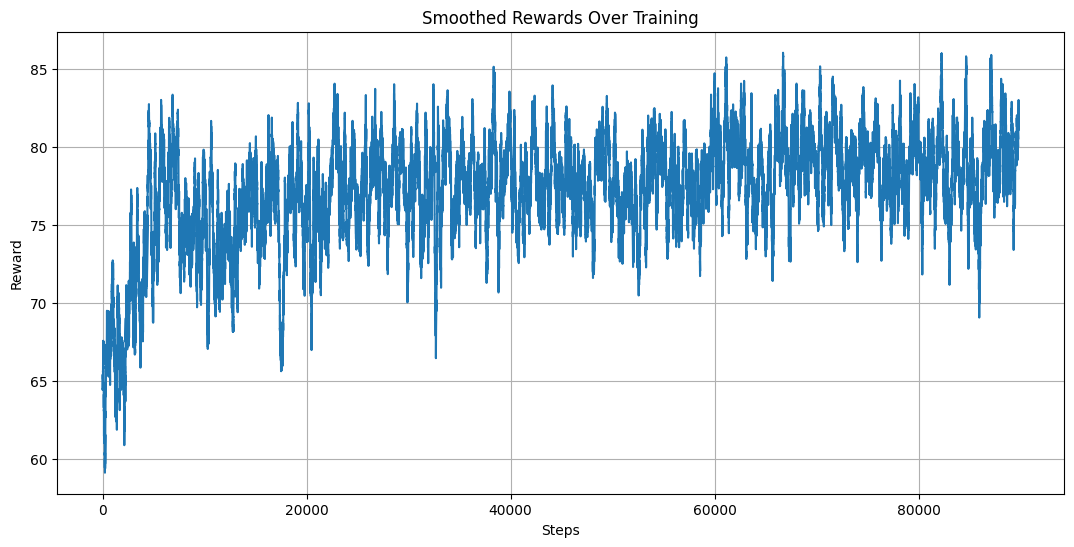

In [9]:
# Plot the rewards after training
plt.figure(figsize=(13, 6))
plt.plot(np.convolve(reward_list, np.ones(200)/200, mode='valid')) #rounded 
#plt.plot(reward_list)
# Smoothed reward plot
plt.title('Smoothed Rewards Over Training')
plt.xlabel('Steps')
plt.ylabel('Reward')
plt.grid()
plt.show()

<h2> Test the model if the logic works

In [10]:
# Example state: [inventory, price_level, demand, competitor_price]
test_state = [0.7, 0.5, 0.5, 210 / 300]  # Example normalized state

# Predict the action for the test state
action, _ = model.predict(test_state, deterministic=True)

# Convert the action to the actual price
price = 150 + action * (300 - 150) / (model.action_space.n - 1)

print(f"Test State: {test_state}")
print(f"Predicted Action: {action}")
print(f"Suggested Price: ${price:.2f}")

Test State: [0.7, 0.5, 0.5, 0.7]
Predicted Action: 131
Suggested Price: $281.88


<h2> Save the model / load and test again

In [11]:
#save model
# Save the trained model as a ZIP FILE
model.save("dqn_airbnb_pricing_model")

In [12]:
from stable_baselines3 import DQN

# Load the trained model
airbnb_model = DQN.load("dqn_airbnb_pricing_model", env=env)  # Pass the environment if you want to continue training
airbnb_model2 = DQN.load("dqn_airbnb_pricing_model")

In [13]:
# Example state: [inventory, price_level, demand, competitor_price]
test_state = [0.8, 0.5, 0.6, 250 / 300]  # Example normalized state

# Predict the action for the test state
action, _ = model.predict(test_state, deterministic=True)

# Convert the action to the actual price
price = 150 + action * (300 - 150) / (model.action_space.n - 1)

print(f"Test State: {test_state}")
print(f"Predicted Action: {action}")
print(f"Suggested Price: ${price:.2f}")

Test State: [0.8, 0.5, 0.6, 0.8333333333333334]
Predicted Action: 98
Suggested Price: $248.66


<h1> Get weekly pricing

In [14]:
def getweeklyprice(model, inventory, price_strategy, demand, competitor_price, low_price, max_price_all):
    price_list=[]
    n_inventory=inventory
    for i in range (4):
                      
        n_demand = demand  - 0.2
        n_competitor_price = competitor_price - (competitor_price *15/100)
        # Example state: [inventory, price_level, demand, competitor_price]
        test_state = [n_inventory, price_strategy, n_demand, n_competitor_price /max_price_all]
        #print(test_state)
        # Example normalized state
        # Predict the action for the test state
        action, _ = model.predict(test_state, deterministic=True)

        # Convert the action to the actual price
        price = low_price + action * (max_price_all - low_price) / (model.action_space.n - 1)

        n_inventory = n_inventory + 0.2 
   
        print(i,price)
    
    for i in range (3):
        inventory = inventory - 0.15   
        eow_demand = demand  + 0.15
        eow_competitor_price = competitor_price + (competitor_price * 10/100)
        # Example state: [inventory, price_level, demand, competitor_price]
        test_state = [inventory, price_strategy, eow_demand, eow_competitor_price /max_price_all]
        #print(test_state)
        # Example normalized state
        # Predict the action for the test state
        action, _ = model.predict(test_state, deterministic=True)

        # Convert the action to the actual price
        price = low_price + action * (max_price_all - low_price) / (model.action_space.n - 1)
         
        print(i,price)
            

In [18]:
#model, inventory, price_strategy, demand, competitor_price, low_price, max_price_all
getweeklyprice(model, .7, .5, .4, 200,170,350)

0 191.74496644295303
1 191.74496644295303
2 192.95302013422818
3 192.95302013422818
0 288.38926174496646
1 288.38926174496646
2 288.38926174496646


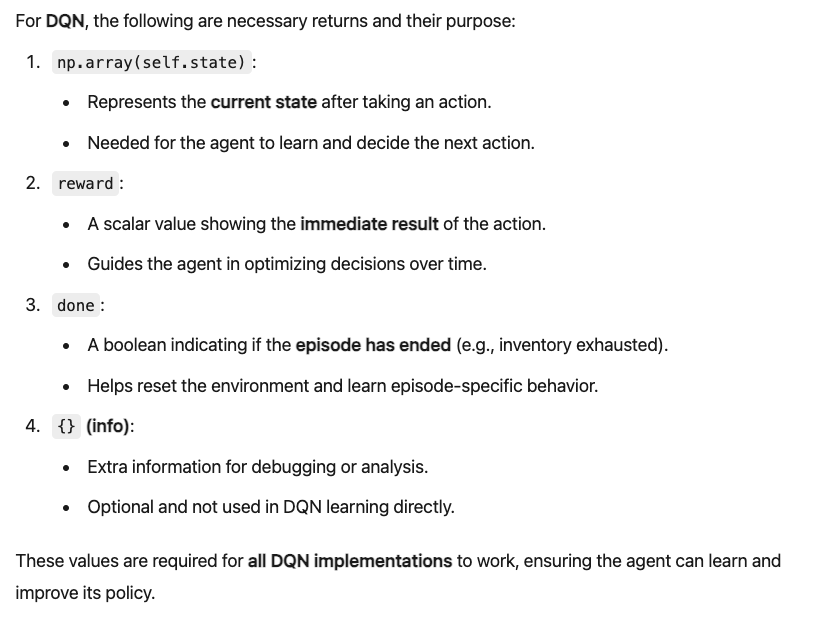